In [41]:
import pandas as pd

In [42]:
df = pd.read_csv("Dados/siga-empreendimentos-geracao.csv", sep=";", encoding="latin-1")
print(df.shape)
df.head()

(25423, 23)


,DatGeracaoConjuntoDados,NomEmpreendimento,IdeNucleoCEG,CodCEG,SigUFPrincipal,SigTipoGeracao,DscFaseUsina,DscOrigemCombustivel,DscFonteCombustivel,DscTipoOutorga,NomFonteCombustivel,DatEntradaOperacao,MdaPotenciaOutorgadaKw,MdaPotenciaFiscalizadaKw,MdaGarantiaFisicaKw,IdcGeracaoQualificada,NumCoordNEmpreendimento,NumCoordEEmpreendimento,DatInicioVigencia,DatFimVigencia,DscPropriRegimePariticipacao,DscSubBacia,DscMuninicpios
0,2026-03-01,E,8,PCH.PH.MG.000008-6.1,MG,PCH,Operação,Hídrica,Potencial hidráulico,Autorização,Potencial hidráulico,1953-11-20,"1400,00",1400,",00",Não,"-20,12479858","-43,87020250",2000-07-07,2030-07-07,100% para ANGLOGOLD ASHANTI CORREGO DO SITIO M...,41 - Das Velhas - Sao Francisco,Nova Lima - MG
1,2026-03-01,F,9,PCH.PH.MG.000009-4.1,MG,PCH,Operação,Hídrica,Potencial hidráulico,Autorização,Potencial hidráulico,1953-11-20,"3972,00",3972,",00",Não,"-20,13187300","-43,87693500",2000-07-07,2030-07-07,100% para ANGLOGOLD ASHANTI CORREGO DO SITIO M...,41 - Das Velhas - Sao Francisco,Nova Lima - MG
2,2026-03-01,G,10,PCH.PH.MG.000010-8.1,MG,PCH,Operação,Hídrica,Potencial hidráulico,Autorização,Potencial hidráulico,1937-01-01,"1440,00",1440,",00",Não,"-20,13754468","-43,89192620",2000-08-31,2030-08-31,100% para ANGLOGOLD ASHANTI CORREGO DO SITIO M...,41 - Das Velhas - Sao Francisco,Nova Lima - MG
3,2026-03-01,14 de Julho,12,UHE.PH.RS.000012-4.1,RS,UHE,Operação,Hídrica,Potencial hidráulico,Concessão,Potencial hidráulico,2008-12-25,"100000,00",100000,"45200,00",Não,"-29,06475278","-51,67494167",2001-03-15,2039-11-13,100% para CERAN - COMPANHIA ENERGETICA RIO DAS...,86 - Taquari,"Bento Gonçalves - RS, Cotiporã - RS"
4,2026-03-01,Abaúna,15,CGH.PH.RS.000015-9.1,RS,CGH,Operação,Hídrica,Potencial hidráulico,Registro,Potencial hidráulico,2000-10-15,"720,00",720,"510,00",Não,"-27,82377500","-52,06999722",NaN,NaN,100% para CRERAL- COOPERATIVA DE GERACAO DE EN...,"72 - Uruguai, Inhanduva, Peixe e outros",Floriano Peixoto - RS


In [43]:
df.columns

Index(['DatGeracaoConjuntoDados', 'NomEmpreendimento', 'IdeNucleoCEG',
       'CodCEG', 'SigUFPrincipal', 'SigTipoGeracao', 'DscFaseUsina',
       'DscOrigemCombustivel', 'DscFonteCombustivel', 'DscTipoOutorga',
       'NomFonteCombustivel', 'DatEntradaOperacao', 'MdaPotenciaOutorgadaKw',
       'MdaPotenciaFiscalizadaKw', 'MdaGarantiaFisicaKw',
       'IdcGeracaoQualificada', 'NumCoordNEmpreendimento',
       'NumCoordEEmpreendimento', 'DatInicioVigencia', 'DatFimVigencia',
       'DscPropriRegimePariticipacao', 'DscSubBacia', 'DscMuninicpios'],
      dtype='object')

In [44]:
pd.set_option('display.max_columns', None)

In [45]:
new_df = df[[
    'CodCEG', 'SigTipoGeracao', 'DscOrigemCombustivel', 'DscFonteCombustivel',
    'MdaPotenciaOutorgadaKw', 'NumCoordNEmpreendimento', 'NumCoordEEmpreendimento',
    'DatInicioVigencia', 'DatFimVigencia'
]]

new_df.head()

,CodCEG,SigTipoGeracao,DscOrigemCombustivel,DscFonteCombustivel,MdaPotenciaOutorgadaKw,NumCoordNEmpreendimento,NumCoordEEmpreendimento,DatInicioVigencia,DatFimVigencia
0,PCH.PH.MG.000008-6.1,PCH,Hídrica,Potencial hidráulico,"1400,00","-20,12479858","-43,87020250",2000-07-07,2030-07-07
1,PCH.PH.MG.000009-4.1,PCH,Hídrica,Potencial hidráulico,"3972,00","-20,13187300","-43,87693500",2000-07-07,2030-07-07
2,PCH.PH.MG.000010-8.1,PCH,Hídrica,Potencial hidráulico,"1440,00","-20,13754468","-43,89192620",2000-08-31,2030-08-31
3,UHE.PH.RS.000012-4.1,UHE,Hídrica,Potencial hidráulico,"100000,00","-29,06475278","-51,67494167",2001-03-15,2039-11-13
4,CGH.PH.RS.000015-9.1,CGH,Hídrica,Potencial hidráulico,"720,00","-27,82377500","-52,06999722",NaN,NaN


In [46]:
# remove all 2025/2026 DatInicioVigencia
print(new_df.shape)
new_df = new_df[~new_df['DatInicioVigencia'].astype(str).str.contains('2025|2026', na=False)]
print(new_df.shape)

# remove all < 1985 DatInicioVigencia, means that we dont have 
# 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984
new_df = new_df[~new_df['DatInicioVigencia'].astype(str).str.contains('1970|1971|1972|1973|1974|1975|1976|1977|1978|1979|1980|1981|1982|1983|1984', na=False)]
print(new_df.shape)

(25423, 9)
(25316, 9)
(25302, 9)


=== Empreendimentos por Origem de Combustível e Ano ===

AnoInicioVigencia     1986.0  1987.0  1988.0  1992.0  1993.0  1994.0  1995.0  \
DscOrigemCombustivel                                                           
Biomassa                   0       0       0       0       1       0       1   
Eólica                     0       0       0       0       0       0       0   
Fóssil                     1       1       1       0       2       3       3   
Hídrica                    1       0       0       1       1       5       9   
Solar                      0       0       0       0       0       0       0   

AnoInicioVigencia     1996.0  1997.0  1998.0  1999.0  2000.0  2001.0  2002.0  \
DscOrigemCombustivel                                                           
Biomassa                   3       3       2       0       9      18      33   
Eólica                     0       0       0       1       0       6      15   
Fóssil                     1       5       6       7      14  

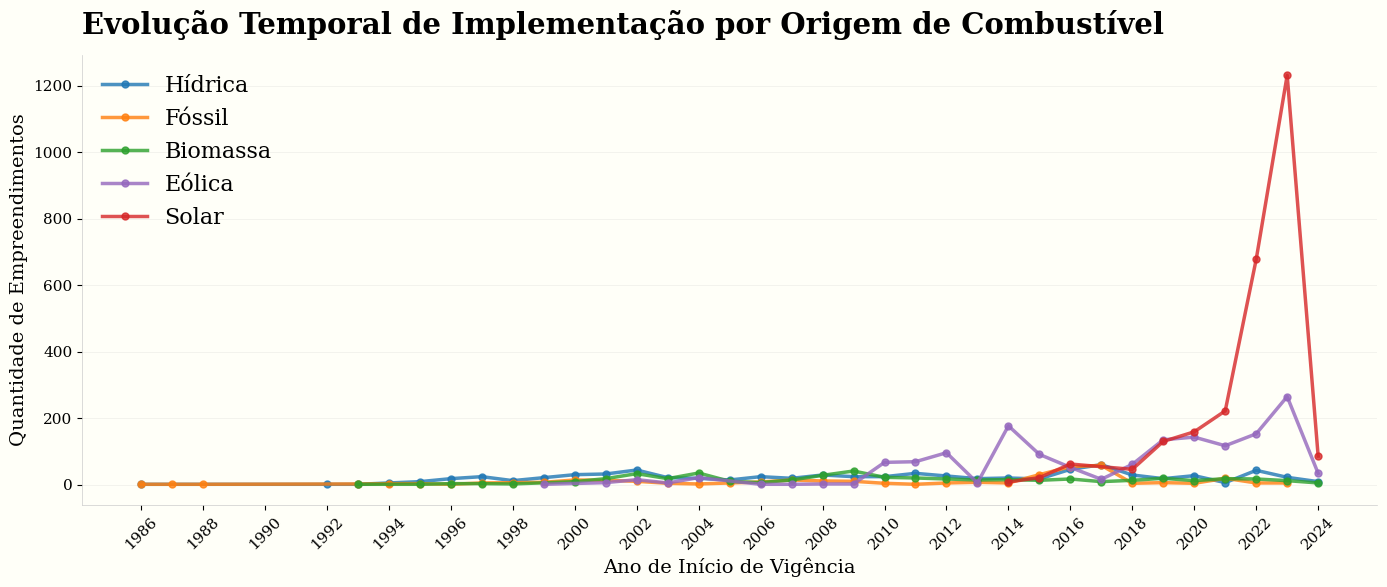

In [61]:
# Converter DatInicioVigencia para datetime
new_df['DatInicioVigencia'] = pd.to_datetime(
    new_df['DatInicioVigencia'], 
    format='%Y-%m-%d',
    errors='coerce'
)

# Extrair ano
new_df['AnoInicioVigencia'] = new_df['DatInicioVigencia'].dt.year

# 1. Distribuição por origem de combustível e ano
print("=== Empreendimentos por Origem de Combustível e Ano ===\n")
dist_ano = new_df.groupby(['DscOrigemCombustivel', 'AnoInicioVigencia']).size().unstack(fill_value=0)
print(dist_ano)

# 2. Primeiro ano de implementação para cada categoria
print("\n=== Primeiro Ano de Implementação por Origem ===\n")
primeiro_ano = new_df.groupby('DscOrigemCombustivel')['AnoInicioVigencia'].min()
print(primeiro_ano.sort_values())

# 3. Período mais ativo (maior concentração) por origem
print("\n=== Pico de Implementação (Ano com Mais Empreendimentos) ===\n")
pico = new_df.groupby('DscOrigemCombustivel')['AnoInicioVigencia'].agg(lambda x: x.value_counts().idxmax())
print(pico.sort_values())

# 4. Total por origem
print("\n=== Total de Empreendimentos por Origem ===\n")
total = new_df['DscOrigemCombustivel'].value_counts()
print(total)

# 5. Série temporal (visualização) Tufte
import matplotlib.pyplot as plt

# === Tufte rcParams ===
TUFTE_RC = {
    "font.family": "serif",
    "font.serif": ["Palatino", "Palatino Linotype", "Georgia", "DejaVu Serif"],
    "font.size": 11,
    "figure.facecolor": "#fffff8",
    "figure.dpi": 100,
    "axes.facecolor": "#fffff8",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
}
plt.rcParams.update(TUFTE_RC)

# Definir paleta de cores
paleta_cores = {
    'Solar': '#d62728',      # Vermelho
    'Hídrica': '#1f77b4',    # Azul
    'Biomassa': '#2ca02c',   # Verde
    'Eólica': '#9467bd',     # Roxo
    'Fósseis': '#8c564b'     # Marrom
}

# Cores padrão para outras categorias
cores_padrao = ['#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
outras_categorias = [cat for cat in new_df['DscOrigemCombustivel'].unique() 
                     if cat not in paleta_cores]
for idx, cat in enumerate(sorted(outras_categorias)):
    paleta_cores[cat] = cores_padrao[idx % len(cores_padrao)]

fig, ax = plt.subplots(figsize=(14, 6))

for origem in new_df['DscOrigemCombustivel'].unique():
    dados = new_df[new_df['DscOrigemCombustivel'] == origem]['AnoInicioVigencia'].value_counts().sort_index()
    cor = paleta_cores.get(origem, '#000000')
    ax.plot(dados.index, dados.values, marker='o', label=origem, linewidth=2.5, 
            markersize=5, color=cor, alpha=0.8)

# Tufte: remover decorações desnecessárias
ax.set_xlabel('Ano de Início de Vigência', fontsize=14)
ax.set_ylabel('Quantidade de Empreendimentos', fontsize=14)

# X ticks a cada 2 anos
ticks = range(int(new_df['AnoInicioVigencia'].min()), int(new_df['AnoInicioVigencia'].max()) + 1, 2)
ax.set_xticks(ticks)
ax.tick_params(axis='x', rotation=45)

ax.set_title('Evolução Temporal de Implementação por Origem de Combustível', 
             fontsize=21, fontweight='bold', loc='left', pad=15)

# Legenda limpa
legend = ax.legend(loc='upper left', fontsize=16, frameon=False)

# Grid minimalista (apenas linhas horizontais)
ax.grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Remover spines (Tufte: range-frame)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [39]:
new_df.iloc[0].to_json()

'{"CodCEG":"PCH.PH.MG.000008-6.1","SigTipoGeracao":"PCH","DscOrigemCombustivel":"H\\u00eddrica","DscFonteCombustivel":"Potencial hidr\\u00e1ulico","MdaPotenciaOutorgadaKw":"1400,00","NumCoordNEmpreendimento":"-20,12479858","NumCoordEEmpreendimento":"-43,87020250","DatInicioVigencia":"2000-07-07","DatFimVigencia":"2030-07-07"}'

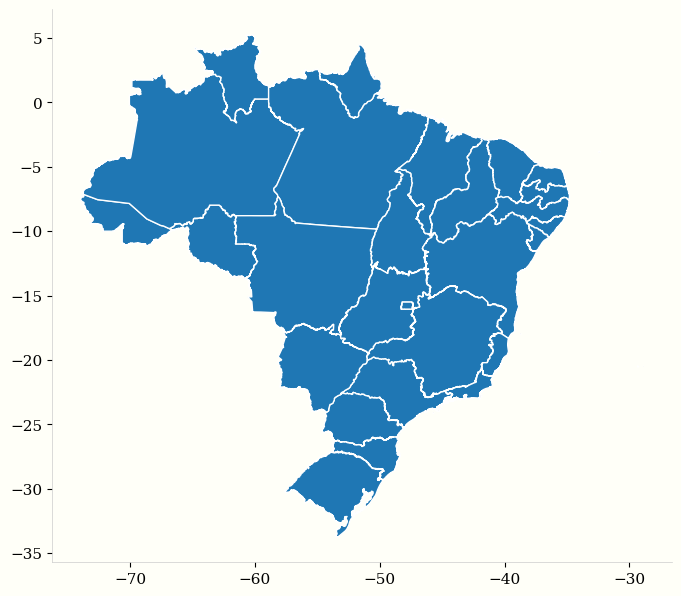

In [40]:
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt

br = geobr.read_state(year=2020)
ax = br.plot(figsize=(8, 10), edgecolor="white")
plt.show()

In [41]:
new_df['DatFimVigencia'].sort_values(ascending=False).value_counts()[:5]

DatFimVigencia
2057-11-25    67
2058-04-25    65
2058-04-11    53
2057-04-26    51
2056-05-25    49
Name: count, dtype: int64

In [42]:
new_df['SigTipoGeracao'].value_counts()

SigTipoGeracao
UFV    19304
UTE     3111
EOL     1569
CGH      710
PCH      506
UHE      220
UTN        3
Name: count, dtype: int64

In [43]:
new_df['DscFonteCombustivel'].value_counts()

DscFonteCombustivel
Radiação solar              19304
Petróleo                     2196
Cinética do vento            1569
Potencial hidráulico         1436
Agroindustriais               481
Gás natural                   193
Floresta                      146
Resíduos sólidos urbanos       42
Carvão mineral                 22
Resíduos animais               20
Biocombustíveis líquidos        7
Outros Fósseis                  4
Urânio                          3
Name: count, dtype: int64

/tmp/ipykernel_34487/2368711727.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['geometry'] = gpd.points_from_xy(


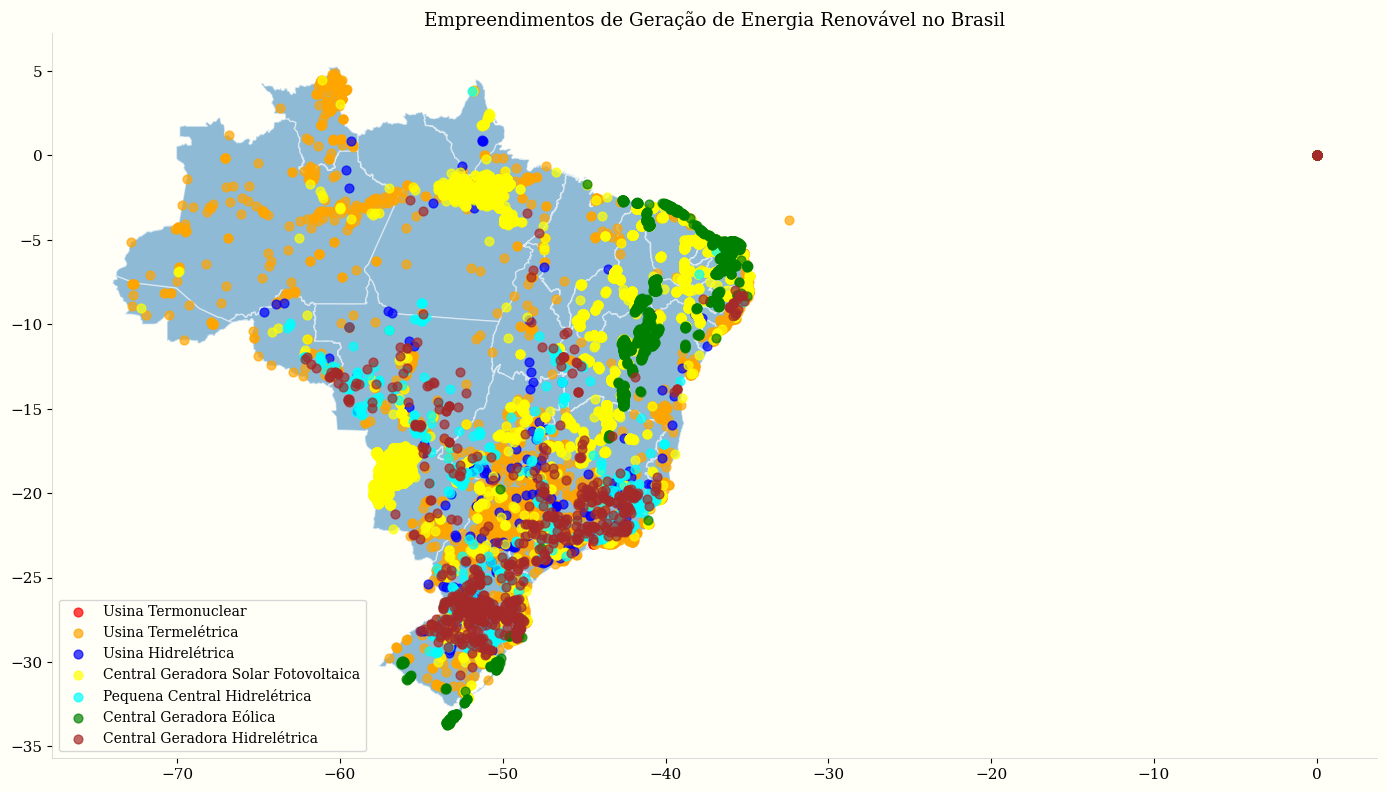

In [44]:
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt

run_again = True

if run_again:
    # Carregar mapa do Brasil
    br = geobr.read_state(year=2020)
    ax = br.plot(figsize=(14, 12), edgecolor="white", alpha=0.5)

    # Converter coordenadas para GeoDataFrame
    new_df['geometry'] = gpd.points_from_xy(
        new_df['NumCoordEEmpreendimento'].astype(str).str.replace(',', '.').astype(float),
        new_df['NumCoordNEmpreendimento'].astype(str).str.replace(',', '.').astype(float)
    )

    gdf = gpd.GeoDataFrame(new_df, geometry='geometry', crs='EPSG:4326')

    # Cores e nomes para cada tipo de geração
    tipos_geracao = {
        'UTN': ('red', 'Usina Termonuclear'),
        'UTE': ('orange', 'Usina Termelétrica'),
        'UHE': ('blue', 'Usina Hidrelétrica'),
        'UFV': ('yellow', 'Central Geradora Solar Fotovoltaica'),
        'PCH': ('cyan', 'Pequena Central Hidrelétrica'),
        'EOL': ('green', 'Central Geradora Eólica'),
        'CGU': ('purple', 'Central Geradora Undi-elétrica'),
        'CGH': ('brown', 'Central Geradora Hidrelétrica')
    }

    # Plotar cada tipo de geração com uma cor diferente
    for tipo_geracao, (cor, nome_oficial) in tipos_geracao.items():
        gdf_tipo = gdf[gdf['SigTipoGeracao'] == tipo_geracao]
        if not gdf_tipo.empty:
            gdf_tipo.plot(ax=ax, alpha=0.7, markersize=40, color=cor, label=nome_oficial)

    plt.title('Empreendimentos de Geração de Energia Renovável no Brasil')
    plt.legend(loc='best', fontsize=10)
    plt.tight_layout()
    plt.show()

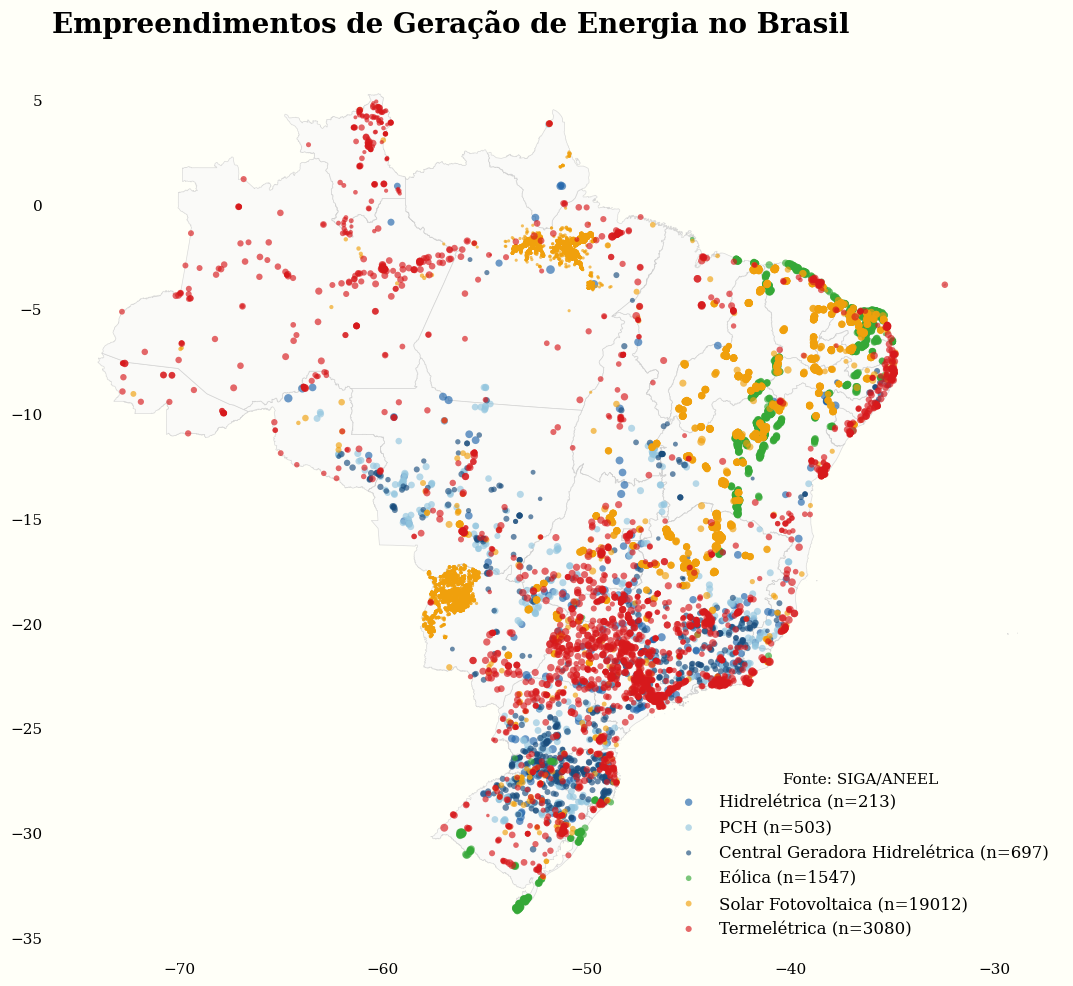

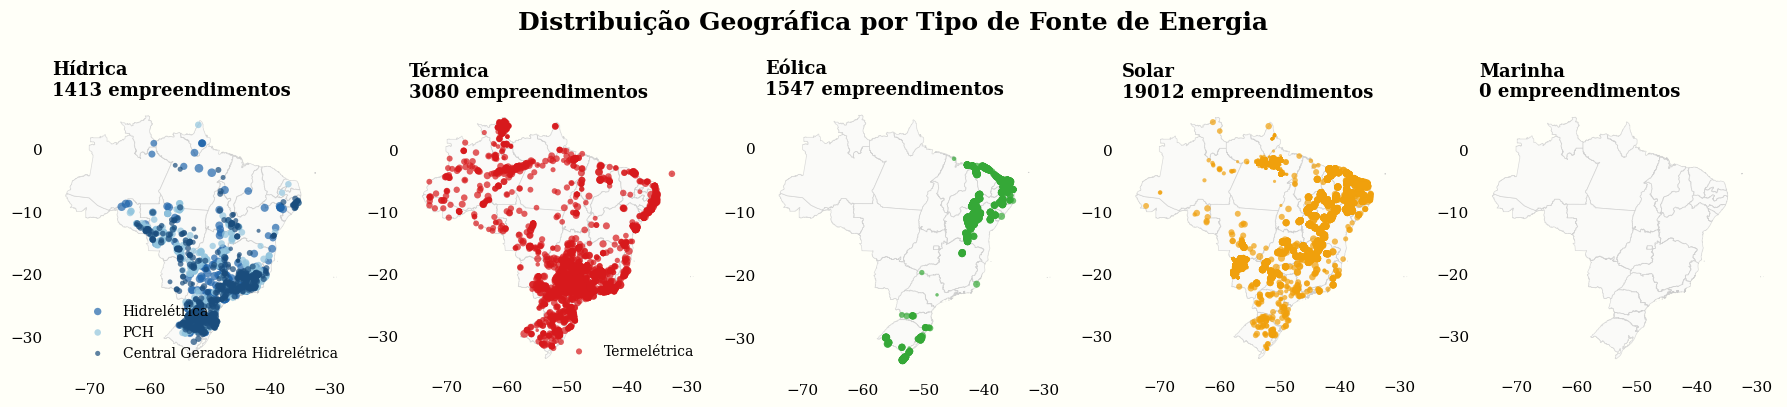

In [55]:
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# === Tufte rcParams ===
TUFTE_RC = {
    "font.family": "serif",
    "font.serif": ["Palatino", "Palatino Linotype", "Georgia", "DejaVu Serif"],
    "font.size": 11,
    "figure.facecolor": "#fffff8",
    "figure.dpi": 100,
    "axes.facecolor": "#fffff8",
    "axes.edgecolor": "#cccccc",
    "axes.linewidth": 0.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
}
plt.rcParams.update(TUFTE_RC)

# === Cores Tufte: Gray default + selective highlights ===
TUFTE_COLORS = {
    'UHE': '#2166ac',  # Hidrelétrica: azul (principal)
    'PCH': '#92c5de',  # Pequena Central: azul claro
    'CGH': '#1a4d7d',  # Central Geradora Hidrelétrica: azul escuro
    'EOL': '#35a837',  # Eólica: verde
    'UFV': '#f0a00c',  # Solar: laranja dourado
    'UTE': '#d7191c',  # Termelétrica: vermelho
    'UTN': '#8b0000',  # Termonuclear: vermelho escuro
    'CGU': '#9e7bb5',  # Marinha: roxo
}

NOMES_GERACAO = {
    'UTN': 'Termonuclear',
    'UTE': 'Termelétrica',
    'UHE': 'Hidrelétrica',
    'UFV': 'Solar Fotovoltaica',
    'PCH': 'PCH',
    'EOL': 'Eólica',
    'CGU': 'Marinha',
    'CGH': 'Central Geradora Hidrelétrica'
}

run_again = True

if run_again:
    # Preparar dados
    br = geobr.read_state(year=2020)
    
    # Converter coordenadas
    new_df['NumCoordN'] = pd.to_numeric(
        new_df['NumCoordNEmpreendimento'].astype(str).str.replace(',', '.'),
        errors='coerce'
    )
    new_df['NumCoordE'] = pd.to_numeric(
        new_df['NumCoordEEmpreendimento'].astype(str).str.replace(',', '.'),
        errors='coerce'
    )
    
    # Filtrar válidos dentro do Brasil
    gdf_data = new_df[
        (new_df['NumCoordN'] >= -40) &
        (new_df['NumCoordN'] <= 10) &
        (new_df['NumCoordE'] >= -90) &
        (new_df['NumCoordE'] <= -30)
    ].copy()
    
    # Normalizar potência
    gdf_data['MdaPotenciaOutorgadaKw'] = pd.to_numeric(
        gdf_data['MdaPotenciaOutorgadaKw'].astype(str).str.replace('.', '').str.replace(',', '.'),
        errors='coerce'
    )
    
    # Escala logarítmica para tamanhos (Tufte: proporção visual honesta)
    min_pot = gdf_data['MdaPotenciaOutorgadaKw'].min()
    max_pot = gdf_data['MdaPotenciaOutorgadaKw'].max()
    gdf_data['size'] = 4 + (np.log1p(gdf_data['MdaPotenciaOutorgadaKw']) - np.log1p(min_pot)) / \
                       (np.log1p(max_pot) - np.log1p(min_pot)) * 35
    
    # Criar GeoDataFrame
    gdf_data['geometry'] = gpd.points_from_xy(gdf_data['NumCoordE'], gdf_data['NumCoordN'])
    gdf = gpd.GeoDataFrame(gdf_data, geometry='geometry', crs='EPSG:4326')
    
    # === Plot 1: Visão geral compreensiva ===
    fig, ax = plt.subplots(figsize=(15, 10))
    
    
    # Mapa base (Tufte: background minimalista)
    br.plot(ax=ax, edgecolor='#cccccc', facecolor='#f8f8f8', linewidth=0.5, alpha=0.7)
    
    # Plotar cada tipo
    for tipo in TUFTE_COLORS.keys():
        gdf_tipo = gdf[gdf['SigTipoGeracao'] == tipo]
        if not gdf_tipo.empty:
            gdf_tipo.plot(
                ax=ax,
                markersize=gdf_tipo['size'],
                color=TUFTE_COLORS[tipo],
                alpha=0.65,
                edgecolor='none',
                label=f"{NOMES_GERACAO[tipo]} (n={len(gdf_tipo)})"
            )
    
    # Tufte: remover decorações desnecessárias
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.grid(False)
    ax.set_title('Empreendimentos de Geração de Energia no Brasil',
             fontsize=20, fontweight='bold', loc='left', pad=15)

    
    # Legenda limpa (Tufte: discretamente posicionada)
    legend = ax.legend(
        loc='lower right',
        fontsize=12,
        frameon=False,
        title='Fonte: SIGA/ANEEL',
        title_fontsize=11
    )
    legend.get_title().set_fontweight('normal')
    
    # Remover eixos (Tufte: range-frame)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    
    plt.tight_layout()
    plt.show()
    
    # === Plot 2: Pequenos múltiplos por categoria ===
    categorias = {
        'Hídrica': ['UHE', 'PCH', 'CGH'],
        'Térmica': ['UTE', 'UTN'],
        'Eólica': ['EOL'],
        'Solar': ['UFV'],
        'Marinha': ['CGU']
    }
    
    fig, axes = plt.subplots(1, len(categorias), figsize=(18, 4))
    
    for idx, (categoria, tipos_lista) in enumerate(categorias.items()):
        ax = axes[idx]
        
        # Mapa base
        br.plot(ax=ax, edgecolor='#cccccc', facecolor='#f8f8f8', linewidth=0.5, alpha=0.7)
        
        # Plotar tipos da categoria
        for tipo in tipos_lista:
            gdf_tipo = gdf[gdf['SigTipoGeracao'] == tipo]
            if not gdf_tipo.empty:
                gdf_tipo.plot(
                    ax=ax,
                    markersize=gdf_tipo['size'],
                    color=TUFTE_COLORS[tipo],
                    alpha=0.7,
                    edgecolor='none',
                    label=NOMES_GERACAO[tipo]
                )
        
        # Tufte: títulos assertivos
        count = len(gdf[gdf['SigTipoGeracao'].isin(tipos_lista)])
        ax.set_title(f'{categoria}\n{count} empreendimentos',
                fontsize=13, fontweight='bold', loc='left')

        
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid(False)
        
        # Legenda limpa apenas se houver múltiplos tipos
        if len(tipos_lista) > 1:
            ax.legend(fontsize=10, loc='lower right', frameon=False)
        
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.xaxis.set_ticks_position('none')
        ax.yaxis.set_ticks_position('none')
    
    plt.suptitle('Distribuição Geográfica por Tipo de Fonte de Energia',
             fontsize=18, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()